# Implentación de Clustering Jerárquico y KMEANS


=== Hierarchical (Agglomerative, ward, k=3) ===
Silhouette:         0.4467  (↑ mejor)
Davies-Bouldin:     0.8035  (↓ mejor)
Calinski-Harabasz:  222.72   (↑ mejor)

=== K-Means (k=3, k-means++, n_init=10) ===
Silhouette:         0.4599  (↑ mejor)
Davies-Bouldin:     0.8336  (↓ mejor)
Calinski-Harabasz:  241.90   (↑ mejor)


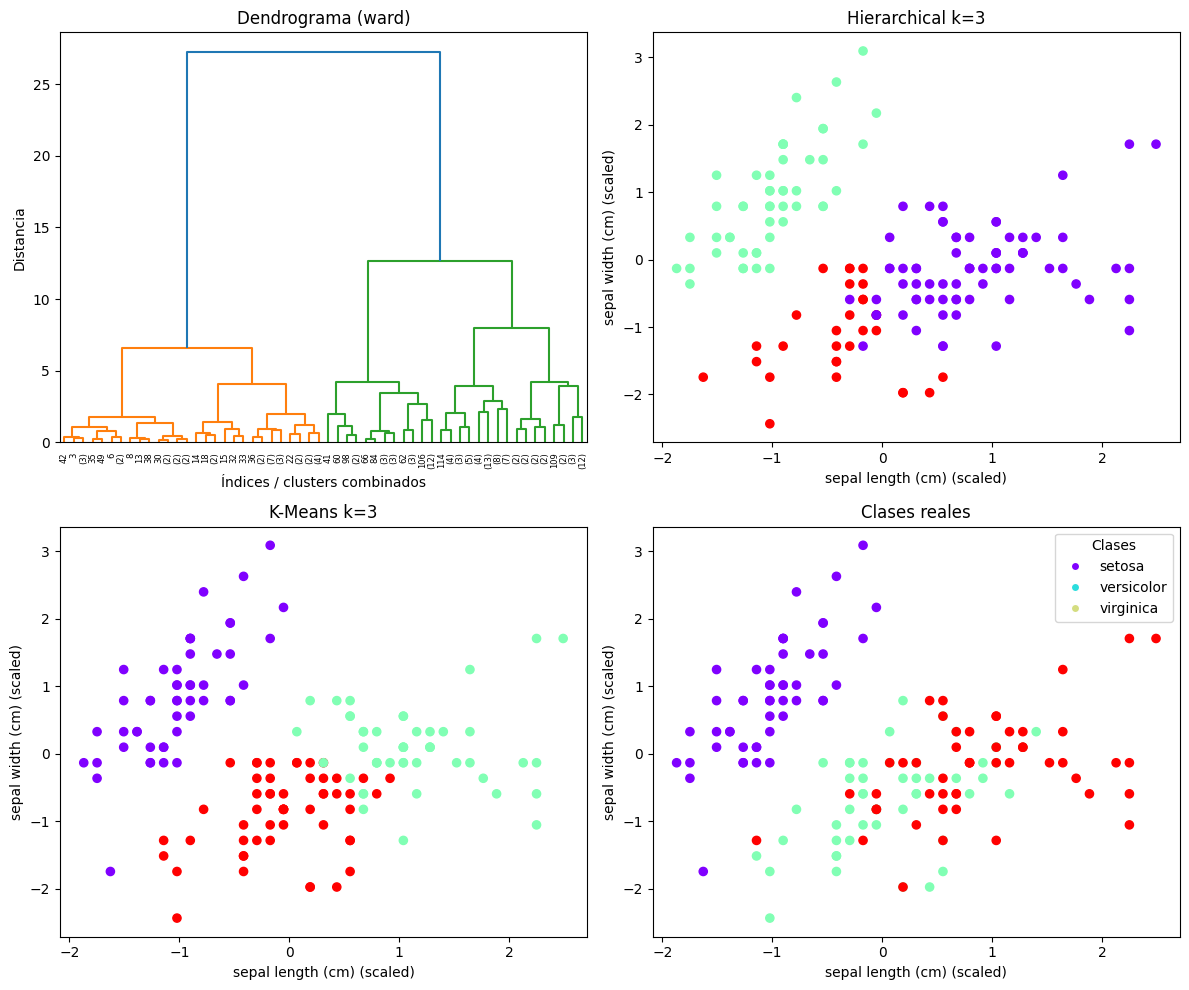

In [2]:
from utils import *
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage

# SEMILLA para reproducibilidad
SEMILLA = 666

# 1) Cargar IRIS SIN etiquetas
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# 2) Escalar
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Para visualizar en 2D
idx_a, idx_b = 0, 1
X2 = Xs[:, [idx_a, idx_b]]
xlab = f"{feature_names[idx_a]} (scaled)"
ylab = f"{feature_names[idx_b]} (scaled)"

# -------------------------
# A) Clustering Jerárquico
# -------------------------
y_true = iris.target
class_names = iris.target_names

Z = linkage(Xs, method="ward")
hier = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_h = hier.fit_predict(Xs)

evaluate_clustering(Xs, labels_h, name="Hierarchical (Agglomerative, ward, k=3)")

# -----------
# B) K-Means
# -----------
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=SEMILLA)
labels_k = kmeans.fit_predict(Xs)

evaluate_clustering(Xs, labels_k, name="K-Means (k=3, k-means++, n_init=10)")

# -------------
# C) Visualización comparativa en un solo lienzo
# -------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# dendrograma
from scipy.cluster.hierarchy import dendrogram

dendrogram(Z, truncate_mode="level", p=5, ax=axs[0, 0])
axs[0, 0].set_title("Dendrograma (ward)")
axs[0, 0].set_xlabel("Índices / clusters combinados")
axs[0, 0].set_ylabel("Distancia")

cmap = plt.cm.rainbow
norm = plt.Normalize(vmin=0, vmax=2)
axs[0, 1].scatter(X2[:, 0], X2[:, 1], c=labels_h, s=35, cmap=cmap, norm=norm)
axs[0, 1].set_title("Hierarchical k=3")
axs[0, 1].set_xlabel(xlab)
axs[0, 1].set_ylabel(ylab)

# k-means (2D) con mismo esquema de colores
axs[1, 0].scatter(X2[:, 0], X2[:, 1], c=labels_k, s=35, cmap=cmap, norm=norm)
axs[1, 0].set_title("K-Means k=3")
axs[1, 0].set_xlabel(xlab)
axs[1, 0].set_ylabel(ylab)

# clases reales (2D) igual
axs[1, 1].scatter(X2[:, 0], X2[:, 1], c=y_true, s=35, cmap=cmap, norm=norm)
axs[1, 1].set_title("Clases reales")
axs[1, 1].set_xlabel(xlab)
axs[1, 1].set_ylabel(ylab)

if class_names is not None:
    handles = []
    for lbl in np.unique(y_true):
        handles.append(plt.Line2D([0], [0], marker="o", color="w",
                                  markerfacecolor=plt.cm.rainbow(lbl / len(class_names)),
                                  markersize=6))
    axs[1, 1].legend(handles, class_names, title="Clases", loc="best")

plt.tight_layout()
plt.show()

# Implementación PCA

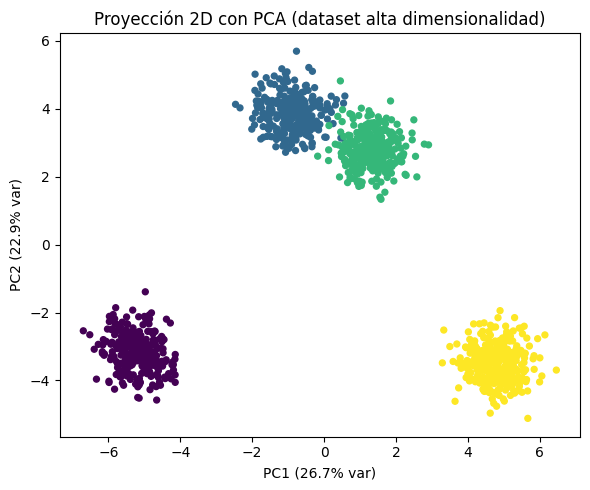

=== PCA Reconstrucción ===
Dimensión original: 50
Componentes usados para ~95% varianza: 35
Varianza explicada acumulada: 95.24%
Error de reconstrucción (MSE): 0.047645


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from utils import reconstruction_error_mse

# 1) Generar dataset de alta dimensionalidad
n_samples = 1200
n_features = 50
n_centers = 4
X, y = make_blobs(
    n_samples=n_samples,
    n_features=n_features,
    centers=n_centers,
    cluster_std=3.0,
    random_state=SEMILLA
)

# Escalado (importante para PCA)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# 2) Aplicar PCA
pca_2d = PCA(n_components=2, random_state=SEMILLA)
X_pca_2d = pca_2d.fit_transform(Xs)

pca_rec = PCA(n_components=0.95, random_state=SEMILLA)
X_pca_k = pca_rec.fit_transform(Xs)
X_reconstructed = pca_rec.inverse_transform(X_pca_k)

# 3) Graficar (proyección 2D)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, s=18)
plt.title("Proyección 2D con PCA")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.show()

# 4) Calcular y mostrar error de reconstrucción
mse = reconstruction_error_mse(Xs, X_reconstructed)
print("=== PCA Reconstrucción ===")
print(f"Dimensión original: {Xs.shape[1]}")
print(f"Componentes usados para ~95% varianza: {pca_rec.n_components_}")
print(f"Varianza explicada acumulada: {np.sum(pca_rec.explained_variance_ratio_)*100:.2f}%")
print(f"Error de reconstrucción (MSE): {mse:.6f}")
